# Two label-free brief-quality detectors, and why neither ships

**What this is.** The diagnostic walk-through for probes `P-FB` (the foreign-brief margin) and
`P-CK` (checkability), both pre-registered in `reports/wf_spec_quality_plan.md` and both costing
$0. Neither needs an LLM, a GPU, or a single label at scoring time — which is exactly why they were
attractive: they would have been the only brief-quality signals available at the moment a brief is
written, before anyone has labelled anything.

**Surface.** All 34 use cases — 6 TIRI (analyst-written briefs) + 28 benchset (briefs derived from
each review's own abstract). Prevalence spans 0.16% to 78%. The two halves are **never averaged
together**: they are two different brief-generation processes, and `DATA_BRIEF.md`'s honest-limit #2
records that deriving a brief from the review's own abstract inflates every brief-reading score.

**Three things to hold onto while reading.**

1. **ROC-AUC 0.500 is a coin flip.** Every score here is "how often does this rank a genuinely
   relevant paper above an irrelevant one". And **a gap under 0.03 is not a result** in this repo —
   re-running with different seeds moves things by ~0.010 on its own (`CONTEXT.md` §5).
2. **One of these probes had already half-happened.** The foreign-brief matrix was computed in
   `wf_usecase_diversity.ipynb` §6 and 7 of its 34 margins were already printed there. So its
   "does this fire too often?" bar could not be read blind, and the genuinely blind test had to be
   something else — see §2.
3. **Both probes fail their bars, and the failures are the useful part.** One kills a caption the
   sibling repo has already registered as shippable; the other kills a metric before either repo
   built it.

In [1]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import spearmanr

sys.path.insert(0, "../../scripts")
from ensemble_eval_utils import partial_rho, spearman_ci

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 200)

REPORTS = Path("../../reports")
FLOOR = 0.03   # CONTEXT.md §5 - gaps under this are not established

# --- chart style -------------------------------------------------------------
# Two categorical hues only (surface identity); validated all-pairs for CVD.
SURF = {"live": "#eb6834", "benchset": "#2a78d6", "tiri": "#eb6834"}
INK, INK2, GRID = "#0b0b0b", "#52514e", "#dcdbd6"
SEQ = LinearSegmentedColormap.from_list("seq", ["#cde2fb", "#6da7ec", "#2a78d6", "#184f95", "#0d366b"])
DIV = LinearSegmentedColormap.from_list("div", ["#0d366b", "#2a78d6", "#f0efec", "#e34948", "#8f1f1f"])

mpl.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 110, "font.size": 9,
    "axes.edgecolor": GRID, "axes.labelcolor": INK2, "axes.titlecolor": INK,
    "axes.titlesize": 10, "axes.titleweight": "bold", "axes.grid": True,
    "grid.color": GRID, "grid.linewidth": 0.6, "xtick.color": INK2, "ytick.color": INK2,
    "axes.spines.top": False, "axes.spines.right": False, "legend.frameon": False,
})


def margins(path):
    """own, best_foreign, who, and the margin, from a brief x corpus AUC matrix."""
    T = pd.read_csv(path, index_col=0)
    own = pd.Series(np.diag(T), index=T.columns)
    off = T.where(~np.eye(len(T), dtype=bool))
    bf = off.max(axis=0)
    return pd.DataFrame({"own": own, "best_foreign": bf, "by": off.idxmax(axis=0),
                         "margin": own - bf})


print("matplotlib", mpl.__version__)

matplotlib 3.11.1


## 1. The margin, and the verification gate that had to pass first

The statistic is one subtraction: **`margin = own_brief_auc − best_foreign_brief_auc`**. Score every
use case's papers with every *other* use case's brief; if a stranger's brief ranks your corpus
better than your own does, your brief is the suspect.

Before reading anything new off this matrix, it has to reproduce the numbers the diversity notebook
already published. That is not ceremony — the matrix is 34×34 and it would be entirely possible to
build it transposed, in which case every "best foreign brief" would silently be "the brief this
corpus best screens" instead, and the whole probe would be about a different question.

In [2]:
J = margins(REPORTS / "wf_foreign_brief_matrix_jasper.csv")
gate = {"soil own": round(J.loc["soil_microbiome", "own"], 3),
        "soil best_foreign": round(J.loc["soil_microbiome", "best_foreign"], 3),
        "soil by": J.loc["soil_microbiome", "by"],
        "mean own": round(J.own.mean(), 3)}
expected = {"soil own": 0.603, "soil best_foreign": 0.792, "soil by": "solar_leo", "mean own": 0.820}
assert gate == expected, f"GATE FAILED: {gate} != {expected}"
print("verification gate: PASS -", gate)

print(f"\n{int((J.margin < 0).sum())} of {len(J)} use cases have a negative margin "
      f"(a stranger's brief beats their own).")
print(f"{int((J.margin < -FLOOR).sum())} of {len(J)} are worse than the {FLOOR} noise floor.\n")
display(J.sort_values("margin").head(8).round(3))

verification gate: PASS - {'soil own': np.float64(0.603), 'soil best_foreign': np.float64(0.792), 'soil by': 'solar_leo', 'mean own': np.float64(0.82)}

7 of 34 use cases have a negative margin (a stranger's brief beats their own).
5 of 34 are worse than the 0.03 noise floor.



,own,best_foreign,by,margin
soil_microbiome,0.603,0.792,solar_leo,-0.190
synergy_moran_2021,0.436,0.616,synergy_menon_2022,-0.180
synergy_menon_2022,0.819,0.893,synergy_wassenaar_2017,-0.075
solar_leo,0.529,0.588,cement_binders,-0.059
synergy_jeyaraman_2020,0.739,0.795,synergy_muthu_2021,-0.056
synergy_sep_2021,0.588,0.617,synergy_menon_2022,-0.029
synergy_wassenaar_2017,0.936,0.956,synergy_van_der_valk_2021,-0.020
synergy_hall_2012,0.991,0.990,synergy_radjenovic_2013,0.002


**Hard finding — the matrix reproduces, and 7 of 34 briefs are beaten by a stranger's.**
`soil_microbiome` scores **0.603** with its own brief and **0.792** with `solar_leo`'s. Read that
plainly: on its own corpus, its own brief lands roughly a fifth of the way from a coin flip (0.500)
to perfect, while a brief written for satellites in low-Earth orbit does substantially better.

**Judgement call, and it is the reason this probe had to be restructured:** these seven margins were
*already printed* in `wf_usecase_diversity.ipynb` §6. The plan's original bar was "≤2 of 34 flag as
broken, and ≥6 of 34 means stop" — a bar that data already on disk had failed before the probe
began, and any threshold chosen now would be fitted to a distribution we can already see. So this
section is **descriptive, not a pre-registered test**, and the blind test is §2.

⚠️ `solar_leo` is a known corpus defect (`CONTEXT.md` §4): its labels track publication year,
because its pool was seeded from citation-ranked canon. It being a strong *screener* of someone
else's corpus is not evidence its own brief is good.

## 2. The blind test — does the margin survive changing representation?

Here is the part that had never been run. The whole 34×34 matrix, rebuilt in **lexical (BM25) space**
instead of embedding space, via the `build_lexical_features(df, brief_map=…)` seam `CONTEXT.md`
L258–260 requires of anything claiming to read a brief.

The logic is simple and it is the only genuinely pre-registered claim in this probe:

> **If a brief is broken, any reader of that brief should notice. If the margin is instead an
> artefact of one embedding's geometry, only that embedding notices.**

Pre-registered bar: of the collections flagged at `margin < −0.03` in cosine space, **≥half must
also flag in lexical space**, and **≤2** may flag in lexical space that cosine called healthy.

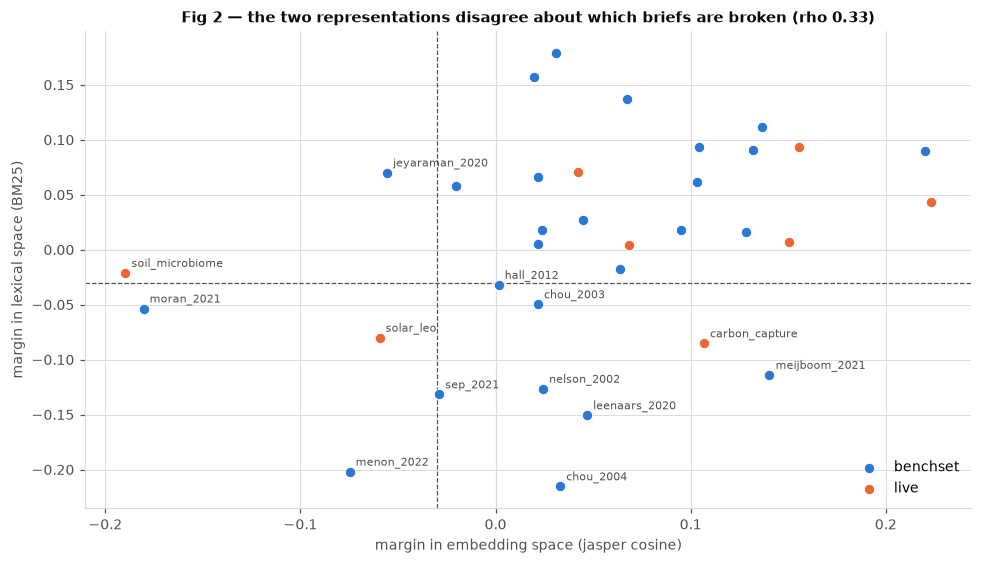

flagged by cosine  (5): ['jeyaraman_2020', 'menon_2022', 'moran_2021', 'soil_microbiome', 'solar_leo']
flagged by lexical (11): ['carbon_capture', 'chou_2003', 'chou_2004', 'hall_2012', 'leenaars_2020', 'meijboom_2021', 'menon_2022', 'moran_2021', 'nelson_2002', 'sep_2021', 'solar_leo']
both               (3): ['menon_2022', 'moran_2021', 'solar_leo']
lexical-only, i.e. cosine called them healthy: 8  (bar allows <=2)

soil_microbiome, the motivating example: cosine -0.190 vs lexical -0.021


In [3]:
L = margins(REPORTS / "wf_foreign_brief_matrix_lexical.csv")
common = J.index.intersection(L.index)
cmp = pd.DataFrame({"cos": J.margin[common], "lex": L.margin[common]}).sort_values("cos")

fc = set(cmp.index[cmp.cos < -FLOOR])
fl = set(cmp.index[cmp.lex < -FLOOR])
rho = spearmanr(cmp.cos, cmp.lex).statistic

fig, ax = plt.subplots(figsize=(9, 5.2))
for stratum, keys in (("benchset", [k for k in cmp.index if k.startswith("synergy_")]),
                      ("live", [k for k in cmp.index if not k.startswith("synergy_")])):
    s = cmp.loc[keys]
    ax.scatter(s.cos, s.lex, s=46, c=SURF[stratum], label=stratum, zorder=3,
               edgecolor="white", linewidth=0.6)
for k in sorted(fc | fl):
    ax.annotate(k.replace("synergy_", ""), (cmp.cos[k], cmp.lex[k]), fontsize=7,
                color=INK2, xytext=(4, 4), textcoords="offset points")
ax.axhline(-FLOOR, color=INK2, lw=0.8, ls="--")
ax.axvline(-FLOOR, color=INK2, lw=0.8, ls="--")
ax.axhline(0, color=GRID, lw=0.8); ax.axvline(0, color=GRID, lw=0.8)
ax.set(xlabel="margin in embedding space (jasper cosine)",
       ylabel="margin in lexical space (BM25)",
       title=f"Fig 2 — the two representations disagree about which briefs are broken (rho {rho:.2f})")
ax.legend(loc="lower right")
plt.tight_layout(); plt.show()

print(f"flagged by cosine  ({len(fc)}): {sorted(x.replace('synergy_','') for x in fc)}")
print(f"flagged by lexical ({len(fl)}): {sorted(x.replace('synergy_','') for x in fl)}")
print(f"both               ({len(fc & fl)}): {sorted(x.replace('synergy_','') for x in fc & fl)}")
print(f"lexical-only, i.e. cosine called them healthy: {len(fl - fc)}  (bar allows <=2)")
print(f"\nsoil_microbiome, the motivating example: cosine {cmp.cos['soil_microbiome']:+.3f} "
      f"vs lexical {cmp.lex['soil_microbiome']:+.3f}")

**Pre-registered bar: FAIL.** Half the cosine-flagged set does carry over (3 of 5, which clears that
half of the bar), but **8 new collections flag in lexical space that cosine called perfectly
healthy** — against a bar of at most 2. The two margins correlate at rho **0.33**, which for a
statistic that is supposed to describe a property of the *text* is close to unrelated.

And the motivating example evaporates: `soil_microbiome`'s margin is **−0.190** in embedding space
and **−0.021** in lexical space — the latter comfortably inside the 0.03 noise floor, i.e. no
detectable problem at all.

**Hard finding — the margin is a property of the embedding, not of the brief.** *ELI18: we tried
the same test with a second, completely different way of matching words to papers. If the brief
itself were badly written, both methods should have complained about the same briefs. Instead they
complained about mostly different ones — so what we were detecting was a quirk of how one model
represents text.*

## 3. So what *does* the margin predict?

A failed detector can still be a real signal pointed at the wrong caption. The pre-registered
validity check joined the margin against two things measured independently of it: how much each
collection **gains from labelling** (`wf_label_budget_shape_grid.csv`) and how much it gains from
**brief induction**.

Predicted sign is **negative**: a brief with a bad margin should be one with more to gain.

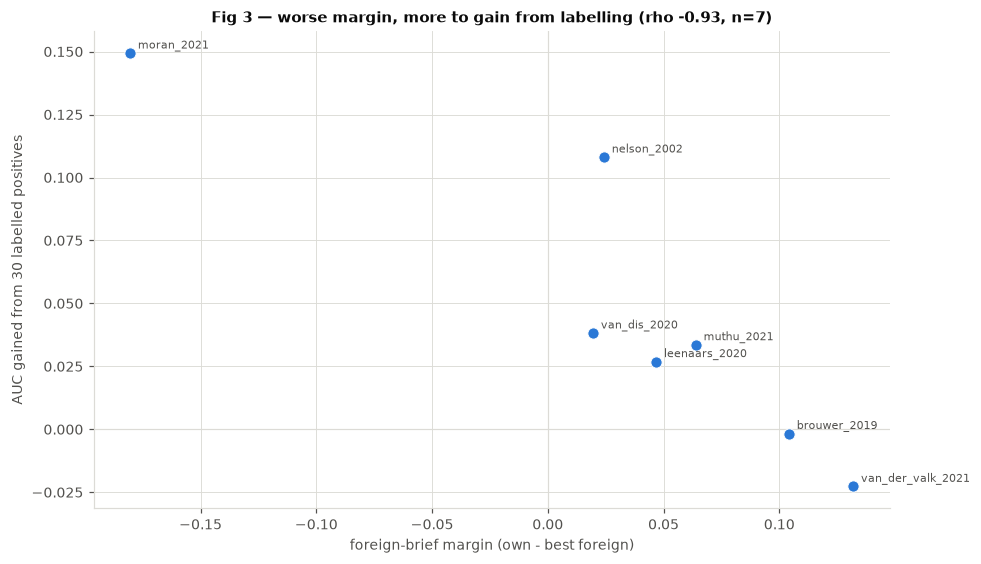

rho = -0.929   p = 0.0025   n = 7   bootstrap CI [-1.000, -0.412]
leave-one-out range: -0.943 to -0.886
partial rho given prevalence is reported in the script; the CI above already excludes zero, but n=7 on a surface with five prior selection passes.


In [4]:
g = pd.read_csv(REPORTS / "wf_label_budget_shape_grid.csv")
gain = g[g.n_pos == 30].groupby("use_case").auc_gain.mean()
keys = [k for k in gain.index if k in J.index]
v = pd.DataFrame({"margin": J.margin.reindex(keys).values,
                  "auc_gain": gain.reindex(keys).values}, index=keys).dropna()

r = spearman_ci(v.margin, v.auc_gain)
jack = {k: round(spearmanr(*v.drop(index=k).T.values).statistic, 3) for k in v.index}

fig, ax = plt.subplots(figsize=(9, 5.2))
ax.scatter(v.margin, v.auc_gain, s=54, c=SURF["benchset"], zorder=3,
           edgecolor="white", linewidth=0.6)
for k in v.index:
    ax.annotate(k.replace("synergy_", ""), (v.margin[k], v.auc_gain[k]), fontsize=7,
                color=INK2, xytext=(5, 3), textcoords="offset points")
ax.axhline(0, color=GRID, lw=0.8); ax.axvline(0, color=GRID, lw=0.8)
ax.set(xlabel="foreign-brief margin (own - best foreign)",
       ylabel="AUC gained from 30 labelled positives",
       title=f"Fig 3 — worse margin, more to gain from labelling (rho {r['rho']:.2f}, n={r['n']})")
plt.tight_layout(); plt.show()

print(f"rho = {r['rho']:+.3f}   p = {r['p']:.4f}   n = {r['n']}   "
      f"bootstrap CI [{r['ci_lo']:+.3f}, {r['ci_hi']:+.3f}]")
print(f"leave-one-out range: {min(jack.values()):+.3f} to {max(jack.values()):+.3f}")
print(f"partial rho given prevalence is reported in the script; the CI above already "
      f"excludes zero, but n={r['n']} on a surface with five prior selection passes.")

**Pre-registered bar: PASS on set A — and then FAIL on set B, which is the read that counts.**

On set A rho is −0.93, surviving every leave-one-out (−0.886 to −0.943), with a bootstrap interval
that excludes zero. That looked strong enough to ship under a different caption. It does not
replicate — see `reports/wf_foreign_brief_validity_setb.md`:

| surface | margin from | rho | 95% CI | rho given prevalence |
|---|---|---|---|---|
| A (burned) | jasper | −0.929 | −1.000 to −0.412 | −0.929 |
| A (burned) | **qwen4b** | **−0.571** | **−1.000 to +0.333** | −0.429 |
| **B (clean)** | **jasper** | **−0.464** | **−1.000 to +0.765** | **+0.143** |
| B (clean) | qwen4b | −0.036 | −0.887 to +1.000 | +0.143 |

**Hard finding — nothing survives.** On the clean surface no margin clears the −0.5 bar, and the sign
**flips positive** once prevalence is held constant — prevalence being the confound already measured
at rho −0.72 against LOGO transfer. And it was never embedding-independent even on set A: the same
statistic on the same rows gives −0.571 for qwen4b, with an interval crossing zero.

*ELI18: on the dataset we had already used for lots of decisions, one model's version of this number
tracked "how much does hand-labelling help" almost perfectly. On a fresh dataset it does not, and
once you account for how rare relevant papers are it points the opposite way. Two other models never
agreed with it even on the original data. So the striking number was a coincidence of one model plus
one dataset — which is exactly what holding a clean dataset in reserve is for.*

⚠️ **The jackknife nearly fooled us, and the lesson generalises.** Surviving leave-one-out reads as
robustness, but **it only tests whether one data point is carrying a correlation — never whether the
whole surface is.** Those are different failure modes and only a different surface tests the second.

**So `NUMBERS.md` N33 should be removed from the screen, not rewritten** — which is the opposite of
what this notebook concluded before the set-B read existed.


## 4. `P-CK` — checkability, and two figures that do not separate anything

Different question, same ambition: say something useful about a use case **before any scoring**.
Two numbers, both deterministic regex over text that already exists:

- **criterion checkability** — of the individual claims in a spec, what share could a machine test
  (a number, a unit, a comparator, a name on a list) rather than requiring a human opinion
  ("promising", "directly transferable")?
- **evidence availability** — of the abstracts in the pool, what share state a number *attached to
  this use case's own named criterion, in the same sentence*?

That last clause is load-bearing. Without it the figure just measures "is this a clinical trial
abstract" — 26 of 28 benchset collections are clinical, and `95% CI`, `p<0.05`, `n=340` would all
count as evidence for a question about cement.

Pre-registered bar: **both figures' pooled IQR ≥ 0.2 across the 34**, surviving a jackknife.

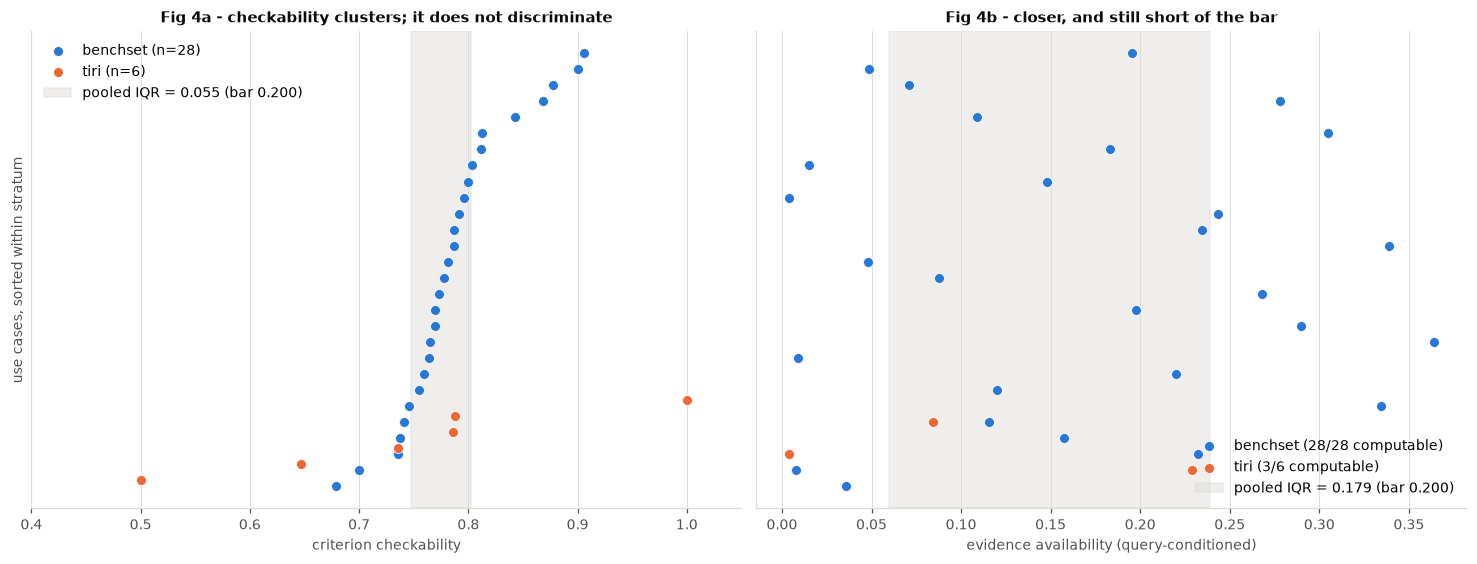

checkability        pooled IQR = 0.055   (bar 0.200)  -> FAIL
evidence            pooled IQR = 0.179   (bar 0.200)  -> FAIL
checkability within TIRI-6 only  IQR = 0.118
checkability within benchset-28  range = 0.679-0.906

evidence uncomputable for: ['carbon_capture', 'soil_microbiome', 'tech_forecasting']  <- NULL, not 0.0

TIRI-6, most to least checkable:


,use_case,checkability,n_classified,evidence_availability
1,cement_binders,1.000,19,0.229
2,ner,0.788,33,0.004
5,tech_forecasting,0.786,28,NaN
3,soil_microbiome,0.735,34,NaN
0,carbon_capture,0.647,17,NaN
4,solar_leo,0.500,20,0.084


In [5]:
ck = pd.read_csv(REPORTS / "wf_checkability_audit.csv")

def iqr(s):
    s = pd.to_numeric(s, errors="coerce").dropna()
    return s.quantile(.75) - s.quantile(.25)

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.2))
ax = axes[0]
for stratum, grp in ck.groupby("stratum"):
    s = grp.sort_values("checkability")
    ax.scatter(s.checkability, np.arange(len(s)) + (0 if stratum == "benchset" else 0.4),
               s=42, c=SURF[stratum], label=f"{stratum} (n={len(s)})", zorder=3,
               edgecolor="white", linewidth=0.5)
ax.axvspan(ck.checkability.quantile(.25), ck.checkability.quantile(.75),
           color=GRID, alpha=0.45, zorder=1,
           label=f"pooled IQR = {iqr(ck.checkability):.3f} (bar 0.200)")
ax.set(xlabel="criterion checkability", ylabel="use cases, sorted within stratum",
       title="Fig 4a - checkability clusters; it does not discriminate", xlim=(0.4, 1.05))
ax.set_yticks([]); ax.legend(loc="upper left")

ax = axes[1]
ev = pd.to_numeric(ck.evidence_availability, errors="coerce")
for stratum, grp in ck.groupby("stratum"):
    e = pd.to_numeric(grp.evidence_availability, errors="coerce")
    ax.scatter(e, np.arange(len(grp)), s=42, c=SURF[stratum], zorder=3,
               edgecolor="white", linewidth=0.5, label=f"{stratum} ({e.notna().sum()}/{len(grp)} computable)")
ax.axvspan(ev.quantile(.25), ev.quantile(.75), color=GRID, alpha=0.45, zorder=1,
           label=f"pooled IQR = {iqr(ev):.3f} (bar 0.200)")
ax.set(xlabel="evidence availability (query-conditioned)", ylabel="",
       title="Fig 4b - closer, and still short of the bar")
ax.set_yticks([]); ax.legend(loc="lower right")
plt.tight_layout(); plt.show()

print(f"checkability        pooled IQR = {iqr(ck.checkability):.3f}   (bar 0.200)  -> FAIL")
print(f"evidence            pooled IQR = {iqr(ev):.3f}   (bar 0.200)  -> FAIL")
print(f"checkability within TIRI-6 only  IQR = {iqr(ck[ck.stratum == 'tiri'].checkability):.3f}")
print(f"checkability within benchset-28  range = "
      f"{ck[ck.stratum == 'benchset'].checkability.min():.3f}-"
      f"{ck[ck.stratum == 'benchset'].checkability.max():.3f}")
print(f"\nevidence uncomputable for: "
      f"{sorted(ck.loc[ev.isna(), 'use_case'])}  <- NULL, not 0.0")
print("\nTIRI-6, most to least checkable:")
display(ck[ck.stratum == "tiri"].sort_values("checkability", ascending=False)
        [["use_case", "checkability", "n_classified", "evidence_availability"]].round(3))

**Pre-registered bar: FAIL, on both figures.** Checkability's pooled IQR is **0.055** against a 0.2
floor; evidence availability gets much closer at **0.179** and still misses. The line is not being
moved now that we can see where it landed.

**And the face-validity check fails too.** The one place this metric could be checked against
something already known: `cement_binders` reaches AUC 1.000 under every model tested *because* its
criteria are checkable predicates (`>50% CO2 vs OPC`, `>=40 MPa @ 28d`), while `tech_forecasting`
has no performance criteria at all and is the hardest use case in the repo. The bar was cement in
the top 2 of 6 and tech-forecasting in the bottom 2. Cement ranks **1st** — and tech-forecasting
ranks **3rd**. A caption built on this would tell an analyst the wrong thing about the very use case
it most needs to warn them about.

**Hard finding, and it is the one worth keeping — evidence availability is uncomputable for 3 of the
6 TIRI use cases, and that absence is the result.** `tech_forecasting`, `soil_microbiome` and
`carbon_capture` name no performance criteria, so there is no vocabulary to condition the evidence
count on. That renders **NULL, never 0.0** (`README.md`: "never found out" and "found nothing" are
different facts). *ELI18: we wanted to ask "do these papers contain the numbers this project cares
about?" and for half our own projects the spec never says which numbers it cares about. The use
cases whose corpora we most want to assess are the ones whose specs don't say what to look for.*

## 5. The check that could not fail — half the metric's definition was inert

`P-CK`'s third bar was a stability check: compute checkability under a **narrow** rulebook and a
**broad** one, and see whether the ranking holds. The broad rulebook widens the judgement-hedge
lexicon with discretion words ("promising", "suitable", "directly transferable") — strictly harder
for a span to qualify as machine-checkable.

It reported rho = 1.000, overlap 10/10, PASS. That number deserved a second look.

In [6]:
diff = (ck.checkability - ck.checkability_broad).abs()
print(f"use cases where narrow and broad agree exactly: {int((diff == 0).sum())} of {len(ck)}")
print(f"maximum absolute difference across all 34: {diff.max()}")
print("\n-> rho = 1.000 because the two series are the SAME series. The check compared a")
print("   rulebook against itself, so it could not have failed.")

# Which rules are actually deciding, then? The judgement lexicon is consulted only at steps 6-7,
# after the comparator / enumerated-example / short-span rules have already resolved a span.
from scipy.stats import spearmanr as _sr
print(f"\nrho(n_classified, checkability): pooled {_sr(ck.n_classified, ck.checkability).statistic:+.3f}",
      end="   ")
for s, grp in ck.groupby("stratum"):
    print(f"{s} {_sr(grp.n_classified, grp.checkability).statistic:+.3f}", end="  ")
print(f"\ndual-fire spans (tripped a predicate AND a judgement rule): {int(ck.n_dual_fire.sum())}")

use cases where narrow and broad agree exactly: 34 of 34
maximum absolute difference across all 34: 0.0

-> rho = 1.000 because the two series are the SAME series. The check compared a
   rulebook against itself, so it could not have failed.

rho(n_classified, checkability): pooled -0.106   benchset -0.356  tiri +0.143  
dual-fire spans (tripped a predicate AND a judgement rule): 369


**Corrected verdict: VACUOUS, not PASS.** `checkability_broad` is identical to `checkability` on all
34 use cases, to a maximum absolute difference of **0.0**. rho = 1.000 is an arithmetic identity, not
agreement between two instruments. *ELI18: we meant to mark the same exam twice with a stricter
marking scheme to see if the grades held. The stricter scheme gave every single answer the same
grade, so we marked it twice with the same scheme and learned nothing the second time.*

**Hard finding — the judgement-hedge lexicon never decided anything**, so "predicate vs judgement
invitation" was settled entirely by the comparator, enumerated-example and short-span rules. Half the
metric's stated definition was doing no work. Anyone re-attempting this should know that before
re-deriving the same definition — including the sibling repo, where `probe_5_checkability.py` is
pre-registered as S-UCQ Q5 and does not exist yet.

🟡 **Judgement call, weakly supported:** the natural suspect is the "≤8 tokens and no finite verb →
machine-checkable" rule sweeping up the short noun phrases that dominate the benchset schema.
Checkability correlates with span count at only rho −0.36 within the benchset stratum and −0.11
pooled, so **the vacuity is a hard fact and the explanation is not established.**

## 6. Read this before quoting any number above

1. **Both probes FAIL their pre-registered bars.** `P-FB` fails cross-instrument specificity;
   `P-CK` fails spread on both figures and face validity. Neither ships as a caption. Both bars
   were fixed in `reports/wf_spec_quality_plan.md` before any measurement, and the Amendment there
   records what was corrected and why — correcting a *premise* before measuring, never a threshold
   after.
2. **`P-FB`'s validity result is exploratory and not independent.** n=7, and both the margin and
   the labelling gain are derived from set A, which has had five selection passes. Robust to
   dropping any single collection is not the same as replicated.
3. **`P-CK` is descriptive by pre-registration.** No correlation against AUC is claimed at n=34,
   because 34 is not one population: it is a union of two schemas, with 26 of the 28 benchset
   collections biomedical/psychology/software-engineering against TIRI's hard-science silos
   (`CONTEXT.md` §§4–5).
4. **The two strata are never pooled into one mean.** Benchset briefs derive from each review's own
   abstract, which inflates every brief-reading score uniformly; TIRI's are analyst-written.
5. **`roadfreight_metareview` is quarantined** at 78% prevalence and is excluded from headline
   counts, and **`solar_leo` is a corpus defect** whose labels track publication year — it appears
   above as `soil_microbiome`'s best foreign screener, which is not evidence of anything about
   `solar_leo`.
6. **What actually came out of this:** one registered-but-unvalidated caption (N33) shown to be
   measuring the embedding rather than the brief and rewritten; one metric killed before either
   repo built it; and one spec defect worth acting on today — half of TIRI's own use cases never
   state what evidence they want.